In [113]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [114]:
words = open("/Users/raghav/Downloads/names.txt",'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [115]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [134]:
import random
random.seed(42)
random.shuffle(words)

In [135]:
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [136]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
          dim = 0
      elif x.ndim == 3:
          dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []


class Embedding:

    def __init__(self,num_embeddings,embeddings_dim):
        self.weight = torch.randn(num_embeddings,embeddings_dim)

    def __call__(self,IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self,x):
        B,T,C = x.shape
        x = x.view(B,T//self.n,C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self,layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)

        self.out = x
        return self.out

    def parameters(self):

        return [p for layer in self.layers for p in layer.parameters()]


In [137]:
g = torch.Generator().manual_seed(2147483647)
n_embd = 10
n_hidden = 200
vocab_size = len(stoi)

model = Sequential([
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(2*n_embd,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(2*n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(2*n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size)
    
])

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

170897


In [138]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []
for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb , Yb = Xtr[ix], Ytr[ix]

    
    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])    


      0/ 200000: 3.4140
  10000/ 200000: 2.2041
  20000/ 200000: 2.3227
  30000/ 200000: 1.7989
  40000/ 200000: 2.0494
  50000/ 200000: 1.6959
  60000/ 200000: 2.2178
  70000/ 200000: 2.2913
  80000/ 200000: 2.1220
  90000/ 200000: 2.2006
 100000/ 200000: 1.9089
 110000/ 200000: 1.9368
 120000/ 200000: 1.6149
 130000/ 200000: 1.9220
 140000/ 200000: 1.9995
 150000/ 200000: 1.8039
 160000/ 200000: 1.7305
 170000/ 200000: 1.3946
 180000/ 200000: 1.7858
 190000/ 200000: 1.6871


In [139]:
for layer in model.layers:
    print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 200)
BatchNorm1d : (32, 4, 200)
Tanh : (32, 4, 200)
FlattenConsecutive : (32, 2, 400)
Linear : (32, 2, 200)
BatchNorm1d : (32, 2, 200)
Tanh : (32, 2, 200)
FlattenConsecutive : (32, 400)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


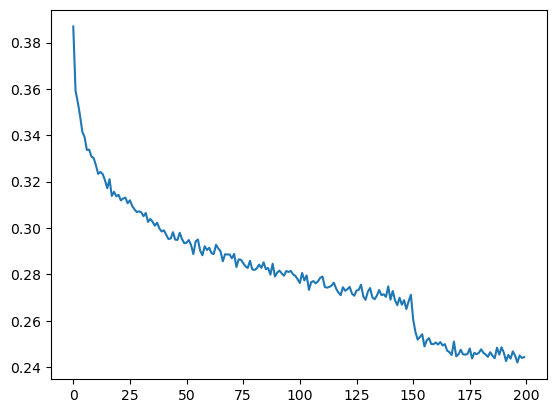

In [140]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [141]:
for layer in model.layers:
    layer.training = False

In [142]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr,Ytr),
        'val' : (Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 1.732255220413208
val 1.9900283813476562


In [146]:
# sample from the model
g2 = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size      # start with all dots [.........] 
    
    while True:
        # forward pass
        x = torch.tensor([context])          # (1, 8)
        logits = model(x)                    # (1, 27)
        probs = F.softmax(logits, dim=1)     # turn scores into probabilities
        
        # sample next character
        ix = torch.multinomial(probs, num_samples=1, generator=g2).item()
        
        # shift context window
        context = context[1:] + [ix]
        
        # collect character
        out.append(ix)
        
        # stop if we hit "."
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out[:-1]))   # print name without the final "."

deximaroul
makinley
yenell
imani
indigan
zakia
krosi
perl
bhrugot
shivan
daniyah
predo
kaleysa
sade
eniavi
rylynn
prigo
devalah
ashdy
draylee
